<a href="https://colab.research.google.com/github/Simran-Dalvi/TensorFlow/blob/main/02_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Larger model

The data for this project is taken from
[Kaggle Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

In [ ]:
# Import required librarie
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


dependent variable - charges

independent variable -  all the other features

In [ ]:
insurance['sex']

,sex
0,female
1,male
2,male
3,male
4,male
...,...
1333,male
1334,female
1335,female
1336,female


To paas through a deep learning mode, we need to convert all features into numerical value.

dtype object would not be taken in during training?

## One hot Encoding

In [ ]:
# Let's try one hot encode our DataFrame
insurance_one_hot = pd.get_dummies(insurance, dtype = int)
insurance_one_hot

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0,0,1,0,0
1334,18,31.920,0,2205.98080,1,0,1,0,1,0,0,0
1335,18,36.850,0,1629.83350,1,0,1,0,0,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0,0,0,0,1


In [ ]:
# Create X and y values (features and labels)
y = insurance_one_hot['charges']
X = insurance_one_hot.drop(['charges'], axis = 1)

X


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,0
1336,21,25.800,0,1,0,1,0,0,0,0,1


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


## Train Test Split

In [ ]:
# Create training and test set 80:20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

len(X), len(X_train), len(X_test)

(1338, 1070, 268)

In [ ]:
X_train # randomly selected the rows

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,46,19.950,2,1,0,1,0,0,1,0,0
1285,47,24.320,0,1,0,1,0,1,0,0,0
1142,52,24.860,0,1,0,1,0,0,0,1,0
969,39,34.320,5,1,0,1,0,0,0,1,0
486,54,21.470,3,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,1,0,1,0,1,0,0,0
1130,39,23.870,5,1,0,1,0,0,0,1,0
1294,58,25.175,0,0,1,1,0,1,0,0,0
860,37,47.600,2,1,0,0,1,0,0,0,1


## Model 1

In [ ]:
# Build a neural network
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#2. Compile the model
insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics = ["mae", "mse"])

#3. Fiting the model
insurance_model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 10383.4248 - mae: 10383.4248 - mse: 238264864.0000
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7734.5903 - mae: 7734.5903 - mse: 163331280.0000
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7614.2422 - mae: 7614.2422 - mse: 163640112.0000
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7470.1982 - mae: 7470.1982 - mse: 152175920.0000
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7325.9038 - mae: 7325.9038 - mse: 156410160.0000
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7357.2144 - mae: 7357.2144 - mse: 156066032.0000
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7197.6235 - mae: 7197.6235 - mse: 149540176.0000
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7607.3408 - mae: 7607.3408 - mse: 157887808.0000
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7782.0542 - mae: 7782.0542 - mse: 162378432.0000 
Epoch 10/100
34/34 ━━━━━

In [ ]:
# Check the results on test data

insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9277.2412 - mae: 9277.2412 - mse: 202082912.0000    


[9007.9765625, 9007.9765625, 196570848.0]

Right now it looks like our model isn't performing too well... lets improve it!

to (try) imporve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and change the optimizer
2. Train for longer with the above model

## Model 2

In [ ]:
tf.random.set_seed(42)

insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae", "mse"])

insurance_model_2.fit(X_train, y_train, epochs = 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 13271.5215 - mae: 13271.5215 - mse: 317671232.0000
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13158.6523 - mae: 13158.6523 - mse: 314490176.0000
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12915.8848 - mae: 12915.8848 - mse: 307748192.0000
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12410.2666 - mae: 12410.2666 - mse: 294119424.0000
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11492.4668 - mae: 11492.4668 - mse: 270599648.0000
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10150.3799 - mae: 10150.3799 - mse: 237188000.0000
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8700.4736 - mae: 8700.4736 - mse: 199713248.0000
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7674.5537 - mae: 7674.5537 - mse: 168471680.0000
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7415.9580 - mae: 7415.9580 - mse: 153482192.0000
Epoch 10/100
34

In [ ]:
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5120.0483 - mae: 5120.0483 - mse: 103598048.0000  


[4965.60107421875, 4965.60107421875, 102446920.0]

## Model 3

In [ ]:
tf.random.set_seed(42)

insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_3.compile(loss = tf.keras.losses.mae,
                          optimizer = tf.keras.optimizers.Adam(),
                          metrics = ["mae", "mse"])

history = insurance_model_3.fit(X_train, y_train, epochs = 200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13280.0723 - mae: 13280.0723 - mse: 317918944.0000
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13158.5430 - mae: 13158.5430 - mse: 314491776.0000
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12889.4609 - mae: 12889.4609 - mse: 307041600.0000
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12329.6152 - mae: 12329.6152 - mse: 292038848.0000
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11330.0381 - mae: 11330.0381 - mse: 266599648.0000
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9931.2930 - mae: 9931.2930 - mse: 231625744.0000
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8494.4639 - mae: 8494.4639 - mse: 193984800.0000
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7598.7349 - mae: 7598.7349 - mse: 164567920.0000
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7417.3931 - mae: 7417.3931 - mse: 152242160.0000
Epoch 10/200
34/

In [ ]:
insurance_model_3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3468.2791 - mae: 3468.2791 - mse: 37147296.0000  


[3402.486083984375, 3402.486083984375, 37891292.0]

## Evaluate

In [ ]:
history.history.keys()


dict_keys(['loss', 'mae', 'mse'])

In [ ]:
metric_dict = {'loss' : history.history['loss'],
       'mae': history.history['mae']}

Text(0, 0.5, 'loss')

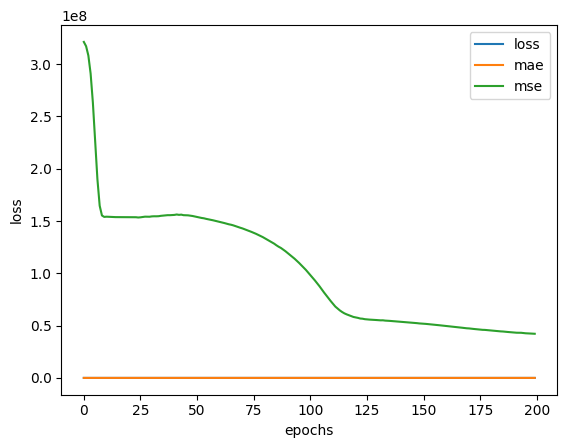

In [ ]:
#Plot history (also known as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.xlabel("epochs")
plt.ylabel("loss")

Text(0, 0.5, 'loss')

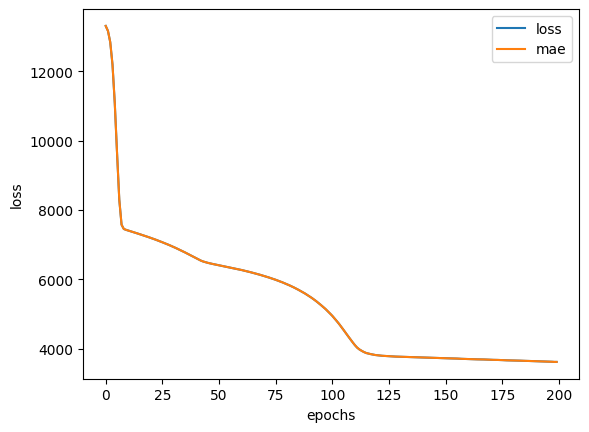

In [ ]:
# Plotting with only mae and loss
pd.DataFrame(metric_dict).plot()
plt.xlabel("epochs")
plt.ylabel("loss")

When should one stop ? What is the ideal number of epochs?

> It depends on the problem. So we use EarlyStopping in Tensorflow

[Early Stopping tensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)

# Preprocessing Data (normalization and Standardization)


In terms of scalling values, neural network tend to prefer normalization.

If not sure which to use, try both and see which performs better.

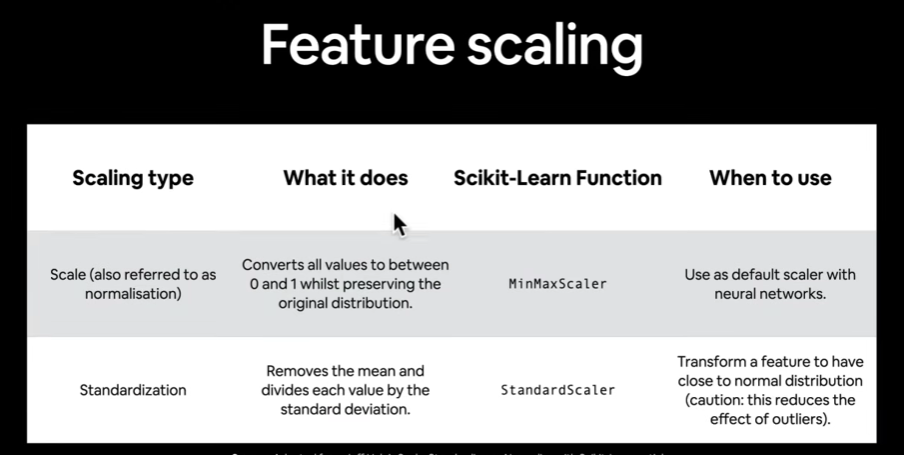

In [ ]:
X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,0
1336,21,25.800,0,1,0,1,0,0,0,0,1


<Axes: ylabel='Frequency'>

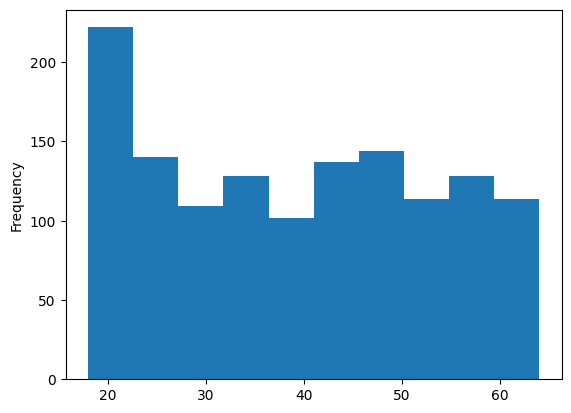

In [ ]:
X['age'].plot(kind = 'hist')

<Axes: ylabel='Frequency'>

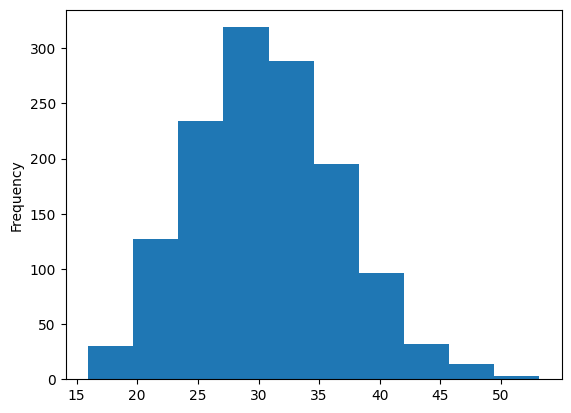

In [ ]:
X['bmi'].plot(kind = 'hist')

In [ ]:
X['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [ ]:
# create a column transfer

ct = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),
    (OneHotEncoder(handle_unknown = 'ignore'), ["sex", "smoker", "region"])
)

In [ ]:
# Create X and y
X = insurance.drop("charges", axis = 1)
y = insurance[["charges"]]

X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [ ]:
# Train and test split them
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [ ]:
# Fit the column transformer to our training data
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
# Transform training and test data with normalization (MinMaxScaler) and OneHotEncoding

X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [ ]:
X_train.loc[0] #this is a pandas data frame

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [ ]:
X_train_normal[0] # it has now turned into numpy.array after transforming

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [ ]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

### Build a model for Normalized data

In [ ]:
# set seed
tf.random.set_seed(42)

# 1. creal the model

insurance_model_normal = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
insurance_model_normal.compile(loss = tf.keras.losses.mae,
                               optimizer = tf.keras.optimizers.Adam(),
                               metrics = ['mae'])

callback = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 5)
# 3. fit the model
history_normal = insurance_model_normal.fit(X_train_normal, y_train, epochs =250, callbacks = [callback])

Epoch 1/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 13297.5771 - mae: 13297.5771
Epoch 2/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13291.7383 - mae: 13291.7383
Epoch 3/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13276.9600 - mae: 13276.9600
Epoch 4/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13243.0967 - mae: 13243.0967
Epoch 5/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13178.6953 - mae: 13178.6953
Epoch 6/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13072.5703 - mae: 13072.5703
Epoch 7/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12913.9678 - mae: 12913.9678
Epoch 8/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12692.6162 - mae: 12692.6162
Epoch 9/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12398.5527 - mae: 12398.5527
Epoch 10/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12022.8574 - mae: 12022.8574
Epoch 11/250
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11571.9082 - mae: 11571.9082
Epoch 12/250
34/34 ━━━━━━━━━━━

In [ ]:
# Evaluating the model
insurance_model_normal.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3213.7996 - mae: 3213.7996  


[3161.046142578125, 3161.046142578125]

Text(0, 0.5, 'Loss')

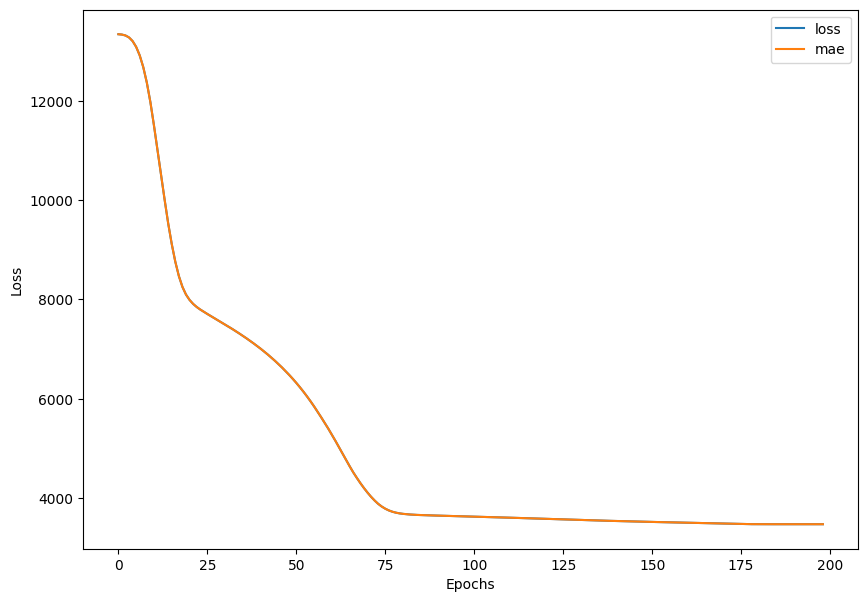

In [ ]:
pd.DataFrame(history_normal.history).plot(figsize=(10,7))
plt.xlabel("Epochs")
plt.ylabel('Loss')